# 🛡️ Insurance Claim Fraud Detection: ML for Regulatory Risk Assessment

**Author:** Dean | Lead Data & AI Engineer  
**Focus:** Detecting fraudulent insurance claims to support prudential regulation and consumer protection  
**Series:** Production ML Portfolio — Australian Government Policy Applications

---

## Executive Summary

This notebook demonstrates a production-grade ML pipeline for detecting fraudulent insurance claims using policyholder demographics, incident details, and claim characteristics. The model supports **automated fraud screening** to triage high-risk claims for investigation, reducing losses while maintaining fair claims processing.

### Government Policy Context
- **APRA (Australian Prudential Regulation Authority)** — Prudential Standard CPS 220 Risk Management, insurer capital adequacy
- **ASIC (Australian Securities & Investments Commission)** — General insurance conduct, claims handling as financial service (post-Hayne Royal Commission)
- **AFCA (Australian Financial Complaints Authority)** — Dispute resolution, unfair claim denial monitoring
- **Treasury** — Insurance Contracts Act 1984, anti-fraud provisions, consumer protection
- **ACCC** — Anti-competitive behaviour in insurance markets, price signalling

### Operational Decision Framework
| Prediction | Action | Stakeholder |
|-----------|--------|-------------|
| Fraud (high confidence) | Route to Special Investigations Unit (SIU) | Fraud team |
| Fraud (borderline) | Enhanced verification, additional documentation | Senior claims assessor |
| Legitimate (high confidence) | Fast-track approval, automated processing | Claims system |
| Legitimate (low confidence) | Standard manual review | Claims officer |

---


## 1. Data Loading & Initial Assessment

In [1]:
import os
import warnings
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import StratifiedKFold
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import (accuracy_score, f1_score, classification_report,
                             confusion_matrix, roc_auc_score, precision_score,
                             recall_score, brier_score_loss)
from sklearn.calibration import calibration_curve
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

warnings.filterwarnings('ignore')
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette('husl')

print("=" * 60)
print("ENVIRONMENT READY")
print("=" * 60)
print(f"NumPy:   {np.__version__}")
print(f"Pandas:  {pd.__version__}")
print("=" * 60)


ENVIRONMENT READY
NumPy:   2.0.2
Pandas:  2.3.3


In [2]:
# === Dynamic path discovery ===
data_path = None
print("Scanning /kaggle/input for data files...")
print("-" * 50)
for root, dirs, files in os.walk('/kaggle/input'):
    for f in files:
        full_path = os.path.join(root, f)
        print(f"  Found: {full_path}")
        if f.endswith('.csv'):
            data_path = full_path
print("-" * 50)

if data_path is None:
    raise FileNotFoundError("No CSV file found in /kaggle/input — check dataset attachment")

print(f"\nUsing: {data_path}")

# === Load with auto separator detection ===
with open(data_path, 'r') as fh:
    sample = fh.read(2048)
sep = ';' if sample.count(';') > sample.count(',') else ','
print(f"Detected separator: '{sep}'")

df = pd.read_csv(data_path, sep=sep)
print(f"\nLoaded: {df.shape[0]:,} rows x {df.shape[1]} columns")
print(f"Memory: {df.memory_usage(deep=True).sum() / 1024:.1f} KB")


Scanning /kaggle/input for data files...
--------------------------------------------------
  Found: /kaggle/input/datasets/shivamb/vehicle-claim-fraud-detection/fraud_oracle.csv
--------------------------------------------------

Using: /kaggle/input/datasets/shivamb/vehicle-claim-fraud-detection/fraud_oracle.csv
Detected separator: ','

Loaded: 15,420 rows x 33 columns
Memory: 21533.1 KB


In [3]:
# === Initial data inspection ===
print("COLUMN SUMMARY")
print("=" * 80)
for i, col in enumerate(df.columns):
    dtype = df[col].dtype
    nuniq = df[col].nunique()
    nulls = df[col].isnull().sum()
    sample_val = df[col].dropna().iloc[0] if len(df[col].dropna()) > 0 else 'N/A'
    has_q = '?' in df[col].astype(str).values if dtype == 'object' else False
    flag = " [has '?']" if has_q else ""
    print(f"  {i:2d}. {col:35s} | {str(dtype):10s} | unique={nuniq:5d} | nulls={nulls:3d}{flag}")

print("\n" + "=" * 80)
print("FIRST 5 ROWS")
print("=" * 80)
df.head()


COLUMN SUMMARY
   0. Month                               | object     | unique=   12 | nulls=  0
   1. WeekOfMonth                         | int64      | unique=    5 | nulls=  0
   2. DayOfWeek                           | object     | unique=    7 | nulls=  0
   3. Make                                | object     | unique=   19 | nulls=  0
   4. AccidentArea                        | object     | unique=    2 | nulls=  0
   5. DayOfWeekClaimed                    | object     | unique=    8 | nulls=  0
   6. MonthClaimed                        | object     | unique=   13 | nulls=  0
   7. WeekOfMonthClaimed                  | int64      | unique=    5 | nulls=  0
   8. Sex                                 | object     | unique=    2 | nulls=  0
   9. MaritalStatus                       | object     | unique=    4 | nulls=  0
  10. Age                                 | int64      | unique=   66 | nulls=  0
  11. Fault                               | object     | unique=    2 | nulls=  0
 

,Month,WeekOfMonth,DayOfWeek,Make,AccidentArea,DayOfWeekClaimed,MonthClaimed,WeekOfMonthClaimed,Sex,MaritalStatus,...,AgeOfVehicle,AgeOfPolicyHolder,PoliceReportFiled,WitnessPresent,AgentType,NumberOfSuppliments,AddressChange_Claim,NumberOfCars,Year,BasePolicy
0,Dec,5,Wednesday,Honda,Urban,Tuesday,Jan,1,Female,Single,...,3 years,26 to 30,No,No,External,none,1 year,3 to 4,1994,Liability
1,Jan,3,Wednesday,Honda,Urban,Monday,Jan,4,Male,Single,...,6 years,31 to 35,Yes,No,External,none,no change,1 vehicle,1994,Collision
2,Oct,5,Friday,Honda,Urban,Thursday,Nov,2,Male,Married,...,7 years,41 to 50,No,No,External,none,no change,1 vehicle,1994,Collision
3,Jun,2,Saturday,Toyota,Rural,Friday,Jul,1,Male,Married,...,more than 7,51 to 65,Yes,No,External,more than 5,no change,1 vehicle,1994,Liability
4,Jan,5,Monday,Honda,Urban,Tuesday,Feb,2,Female,Single,...,5 years,31 to 35,No,No,External,none,no change,1 vehicle,1994,Collision


## 2. Target Variable Identification & Analysis

In [4]:
# === Robust target detection ===
target_candidates = ['FraudFound_P', 'fraud_reported', 'Fraud', 'fraud', 'is_fraud',
                     'Target', 'target', 'Label', 'label', 'Class', 'class']
target_col = None

for candidate in target_candidates:
    if candidate in df.columns:
        target_col = candidate
        print(f"Found target: '{target_col}'")
        break

if target_col is None:
    # Fallback: last column with low cardinality
    last_col = df.columns[-1]
    if df[last_col].nunique() <= 10:
        target_col = last_col
        print(f"Fallback — Using last column: '{target_col}'")

if target_col is None:
    raise ValueError("Could not identify target variable")

print(f"\nRaw target values:")
print(df[target_col].value_counts())

# Encode if string
if df[target_col].dtype == 'object':
    unique_vals = df[target_col].unique().tolist()
    print(f"\nString target detected. Values: {unique_vals}")
    fraud_keywords = ['Y', 'Yes', 'yes', 'TRUE', 'True', '1', 'Fraud', 'fraud']
    mapping = {v: (1 if v in fraud_keywords else 0) for v in unique_vals}
    df[target_col] = df[target_col].map(mapping)
    print(f"Mapping applied: {mapping}")

print(f"\nTarget: '{target_col}'")
print(f"\nDistribution:")
print(df[target_col].value_counts().sort_index())
print(f"\nProportions:")
print(df[target_col].value_counts(normalize=True).sort_index().round(4))

assert df[target_col].nunique() >= 2, f"ERROR: Target has only {df[target_col].nunique()} class after encoding!"

imbalance_ratio = df[target_col].value_counts().min() / df[target_col].value_counts().max()
print(f"\nImbalance ratio: {imbalance_ratio:.3f}")
if imbalance_ratio < 0.5:
    print("Class imbalance detected — stratified CV and per-class metrics essential.")


Found target: 'FraudFound_P'

Raw target values:
FraudFound_P
0    14497
1      923
Name: count, dtype: int64

Target: 'FraudFound_P'

Distribution:
FraudFound_P
0    14497
1      923
Name: count, dtype: int64

Proportions:
FraudFound_P
0    0.9401
1    0.0599
Name: proportion, dtype: float64

Imbalance ratio: 0.064
Class imbalance detected — stratified CV and per-class metrics essential.


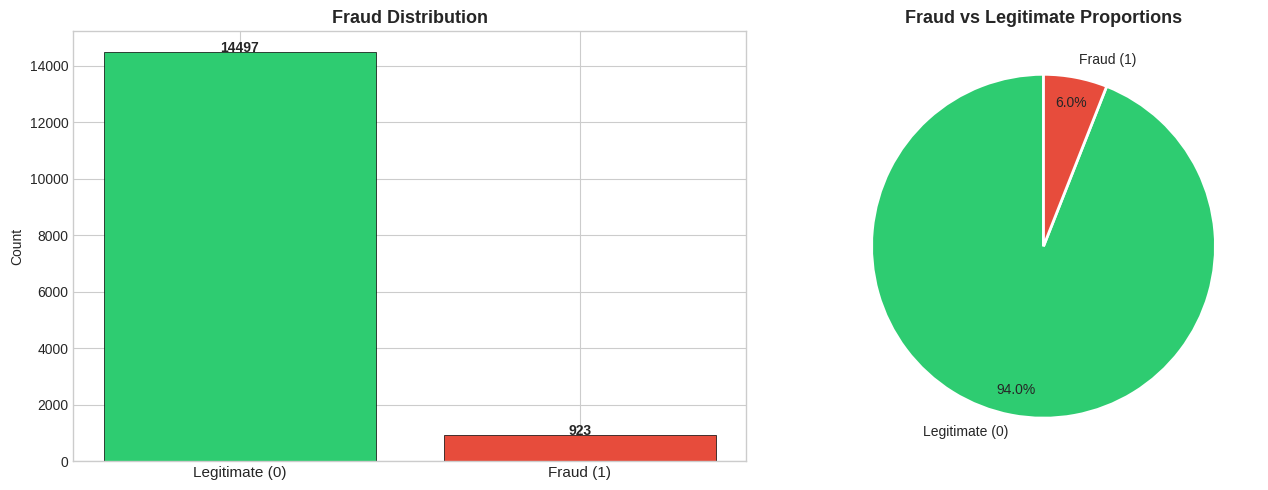

Policy context: Insurance fraud costs the Australian industry ~$2B+ annually (ICA estimates).
False negatives (missed fraud) = direct financial loss. False positives (flagging legitimate) = customer harm.


In [5]:
# === Target distribution visualisation ===
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

vc = df[target_col].value_counts().sort_index()
labels = [f'Class {x}' for x in vc.index]
if len(vc) == 2 and set(vc.index) == {0, 1}:
    labels = ['Legitimate (0)', 'Fraud (1)']
colors = ['#2ecc71', '#e74c3c'] if len(vc) == 2 else sns.color_palette('husl', len(vc))

axes[0].bar(range(len(vc)), vc.values, color=colors, edgecolor='black', linewidth=0.5)
axes[0].set_xticks(range(len(vc)))
axes[0].set_xticklabels(labels, fontsize=11)
axes[0].set_title('Fraud Distribution', fontsize=13, fontweight='bold')
axes[0].set_ylabel('Count')
for i, v in enumerate(vc.values):
    axes[0].text(i, v + 10, str(v), ha='center', fontweight='bold')

axes[1].pie(vc.values, labels=labels, autopct='%1.1f%%', colors=colors,
            startangle=90, pctdistance=0.85, wedgeprops={'edgecolor': 'white', 'linewidth': 2})
axes[1].set_title('Fraud vs Legitimate Proportions', fontsize=13, fontweight='bold')

plt.tight_layout()
plt.savefig('target_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

print("Policy context: Insurance fraud costs the Australian industry ~$2B+ annually (ICA estimates).")
print("False negatives (missed fraud) = direct financial loss. False positives (flagging legitimate) = customer harm.")


## 3. Exploratory Data Analysis

Key questions for insurance regulation:
- What claim/policyholder characteristics correlate with fraud?
- Are certain incident types or policy types higher risk?
- Do temporal patterns exist (time of day, day of week)?
- Are there data quality issues ('?' values) that need handling?


In [6]:
# === Handle '?' values ===
q_counts = {}
for col in df.columns:
    if df[col].dtype == 'object':
        n_q = (df[col] == '?').sum()
        if n_q > 0:
            q_counts[col] = n_q

if q_counts:
    print("COLUMNS WITH '?' PLACEHOLDER VALUES")
    print("=" * 50)
    for col, count in q_counts.items():
        print(f"  {col:35s}: {count} ({count/len(df)*100:.1f}%)")
    print(f"\nTotal '?' values: {sum(q_counts.values())}")
    print("These will be replaced with NaN during preprocessing.")
else:
    print("No '?' placeholder values found.")


No '?' placeholder values found.


Numeric features (7): ['WeekOfMonth', 'WeekOfMonthClaimed', 'Age', 'RepNumber', 'Deductible', 'DriverRating', 'Year']


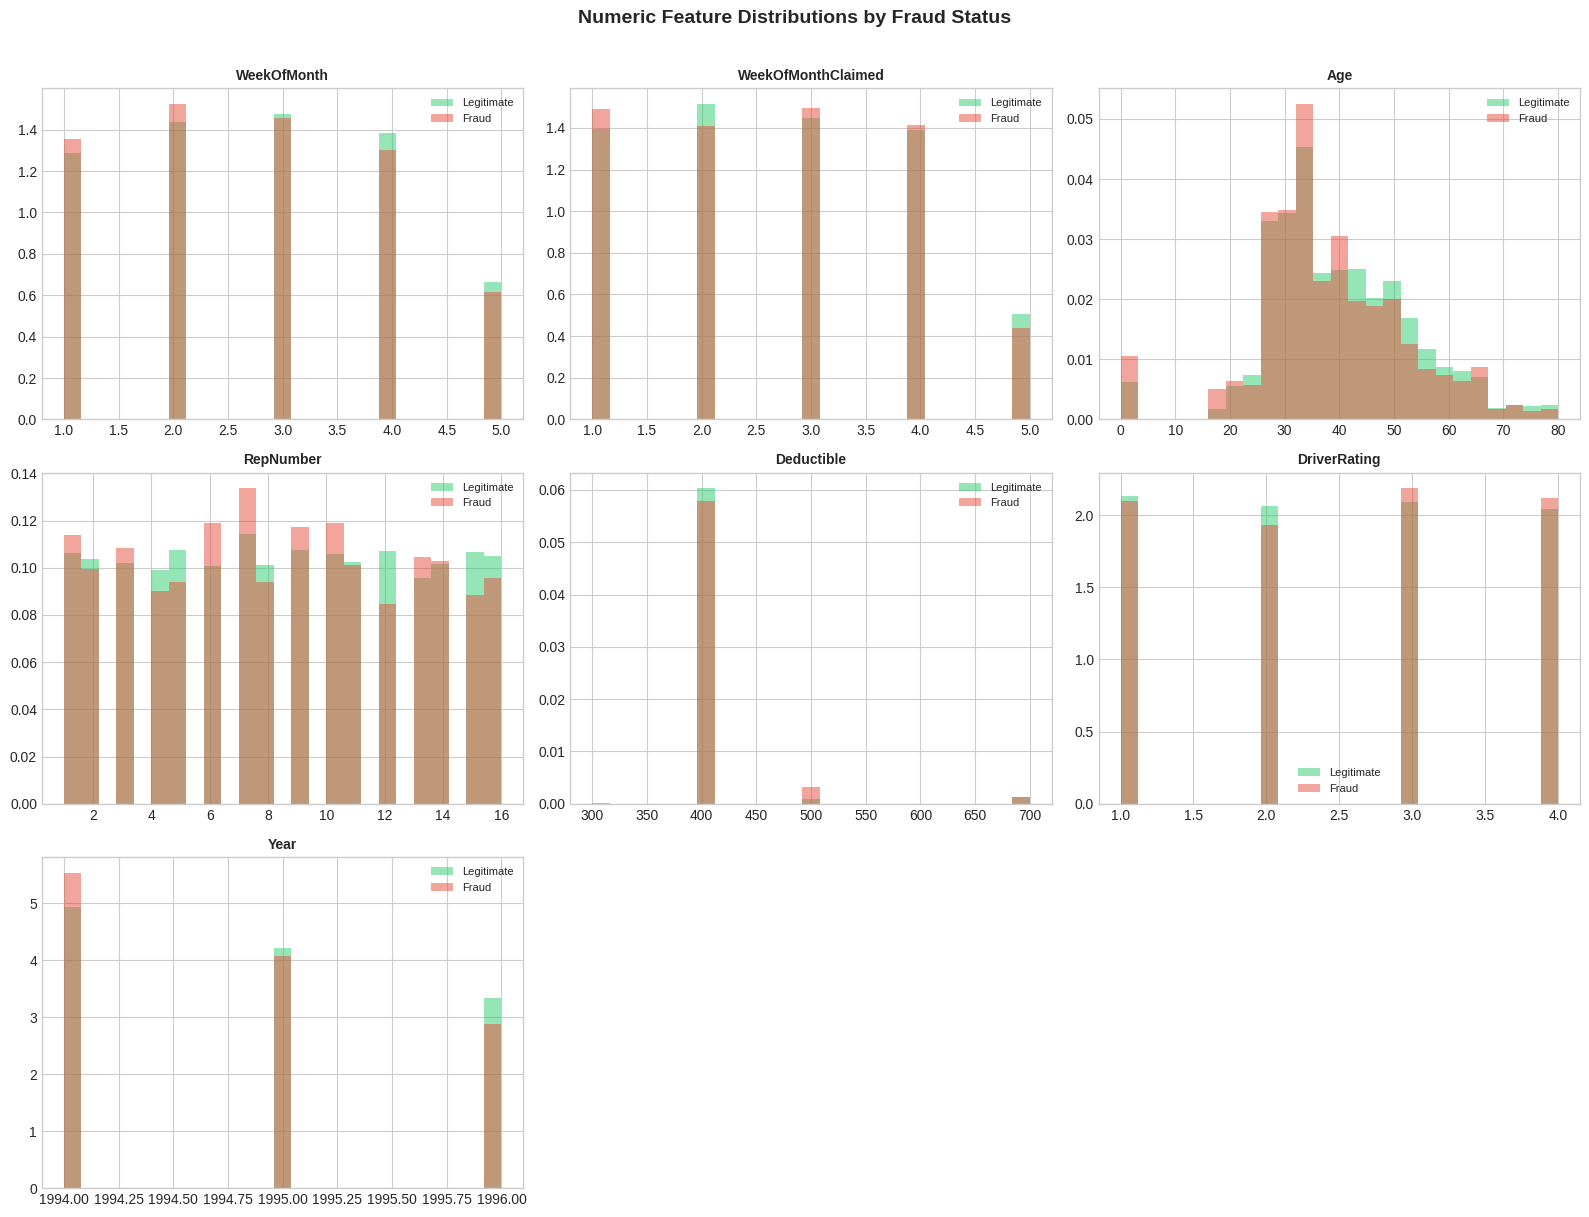

In [7]:
# === Numeric feature distributions by fraud status ===
numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
if target_col in numeric_cols:
    numeric_cols.remove(target_col)
numeric_cols = [c for c in numeric_cols if 'id' not in c.lower() and 'policy_number' not in c.lower()
                and 'policynumber' not in c.lower()]

print(f"Numeric features ({len(numeric_cols)}): {numeric_cols[:15]}")

plot_cols = numeric_cols[:9]
if len(plot_cols) > 0:
    n_cols_p = 3
    n_rows_p = (len(plot_cols) + n_cols_p - 1) // n_cols_p
    fig, axes = plt.subplots(n_rows_p, n_cols_p, figsize=(16, 4 * n_rows_p))
    axes = axes.flatten()

    for i, col in enumerate(plot_cols):
        ax = axes[i]
        for label, color, name in zip(sorted(df[target_col].unique()),
                                       ['#2ecc71', '#e74c3c'], ['Legitimate', 'Fraud']):
            subset = df[df[target_col] == label][col].dropna()
            if len(subset) > 0:
                ax.hist(subset, bins=25, alpha=0.5, label=name, density=True, color=color)
        ax.set_title(col, fontsize=10, fontweight='bold')
        ax.legend(fontsize=8)

    for j in range(i + 1, len(axes)):
        axes[j].set_visible(False)

    plt.suptitle('Numeric Feature Distributions by Fraud Status', fontsize=14, fontweight='bold', y=1.01)
    plt.tight_layout()
    plt.savefig('feature_distributions.png', dpi=150, bbox_inches='tight')
    plt.show()
else:
    print("No numeric features to plot.")


Categorical features for analysis (18): ['Month', 'DayOfWeek', 'DayOfWeekClaimed', 'MonthClaimed', 'Sex', 'MaritalStatus', 'Fault', 'PolicyType', 'VehicleCategory', 'VehiclePrice']


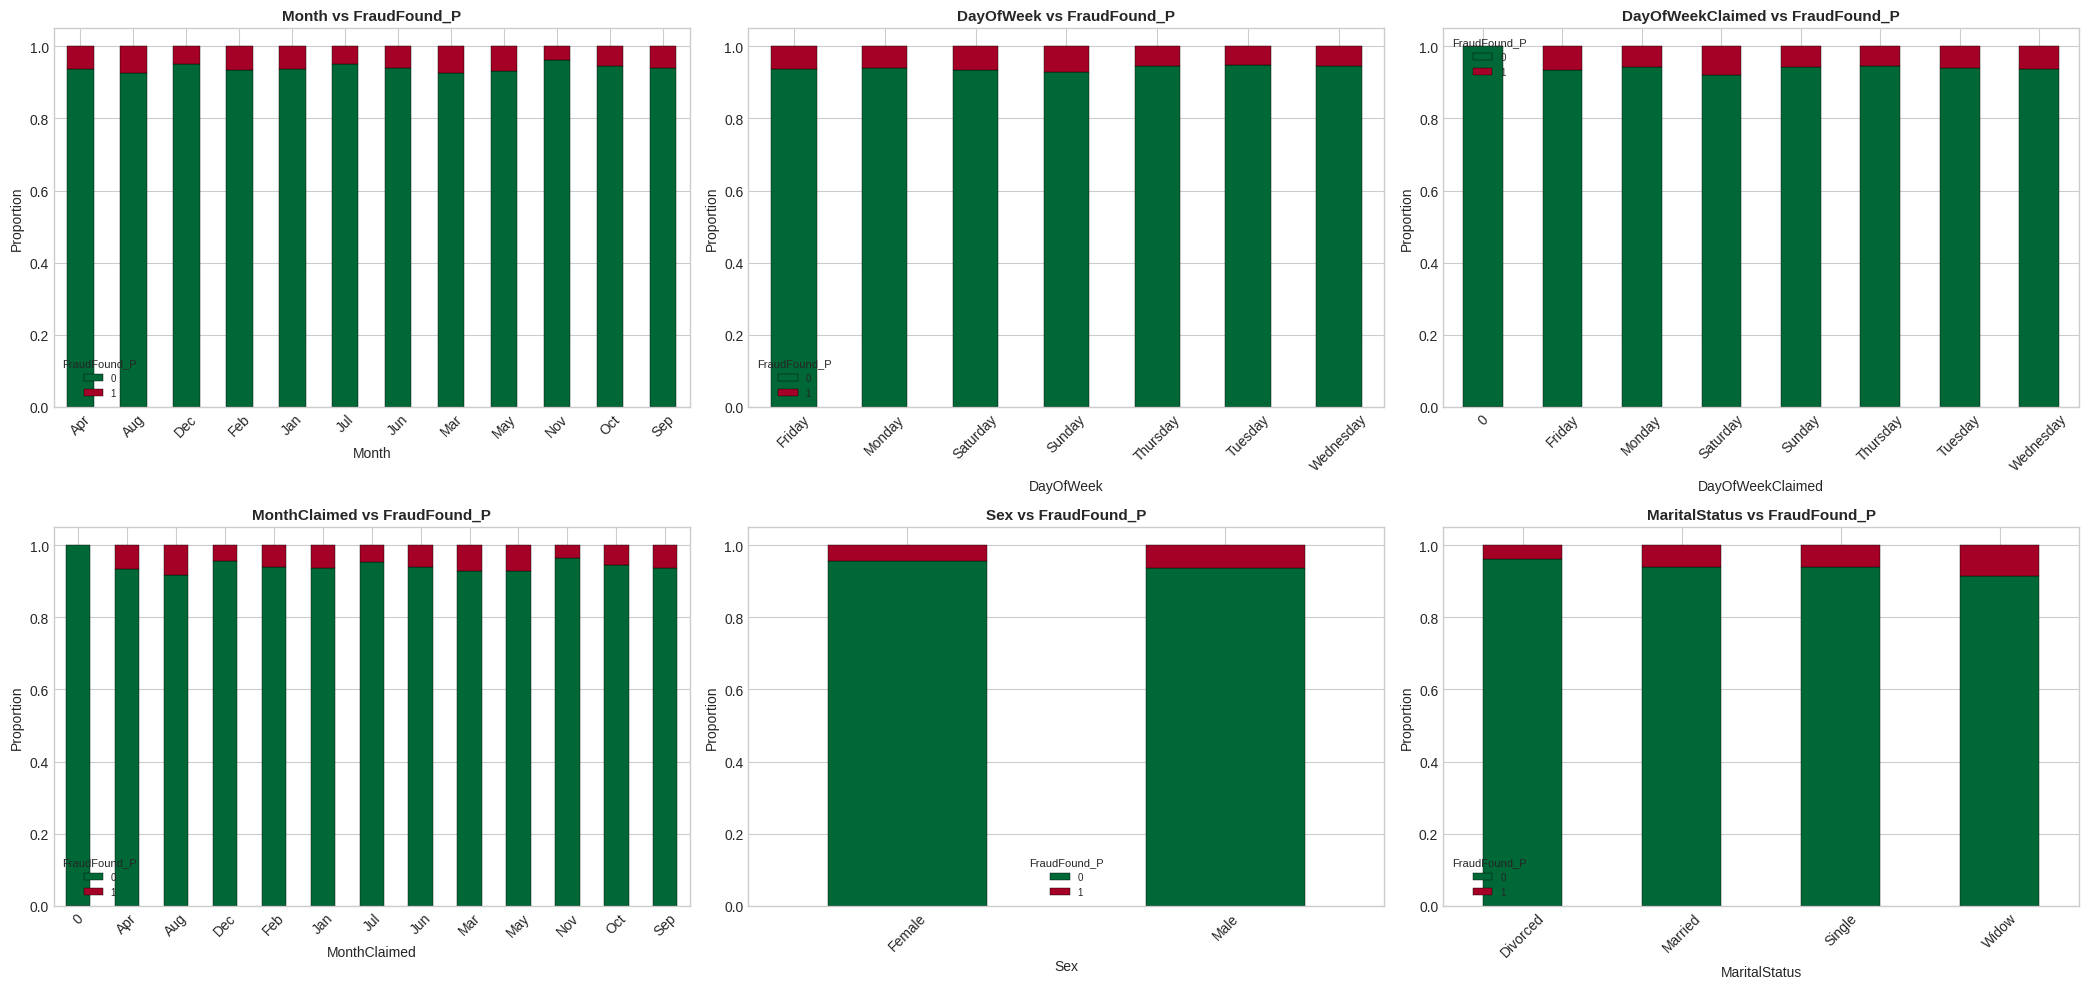

In [8]:
# === Categorical feature analysis ===
cat_cols = df.select_dtypes(include=['object']).columns.tolist()
if target_col in cat_cols:
    cat_cols.remove(target_col)

# Filter to meaningful categoricals
cat_cols = [c for c in cat_cols if df[c].nunique() <= 15 and 'id' not in c.lower()
            and 'number' not in c.lower() and 'date' not in c.lower()]

print(f"Categorical features for analysis ({len(cat_cols)}): {cat_cols[:10]}")

plot_cats = cat_cols[:6]
if len(plot_cats) > 0:
    n_cols_p = min(3, len(plot_cats))
    n_rows_p = (len(plot_cats) + n_cols_p - 1) // n_cols_p
    fig, axes = plt.subplots(n_rows_p, n_cols_p, figsize=(7 * n_cols_p, 5 * n_rows_p))
    if n_rows_p * n_cols_p == 1:
        axes = np.array([axes])
    axes = axes.flatten()

    for i, col in enumerate(plot_cats):
        ct = pd.crosstab(df[col], df[target_col], normalize='index')
        ct.plot(kind='bar', stacked=True, ax=axes[i], colormap='RdYlGn_r',
                edgecolor='black', linewidth=0.3)
        axes[i].set_title(f'{col} vs {target_col}', fontsize=11, fontweight='bold')
        axes[i].set_ylabel('Proportion')
        axes[i].legend(title=target_col, fontsize=7, title_fontsize=8)
        axes[i].tick_params(axis='x', rotation=45)

    for j in range(i + 1, len(axes)):
        axes[j].set_visible(False)

    plt.tight_layout()
    plt.savefig('categorical_analysis.png', dpi=150, bbox_inches='tight')
    plt.show()
else:
    print("No suitable categorical features for plotting.")


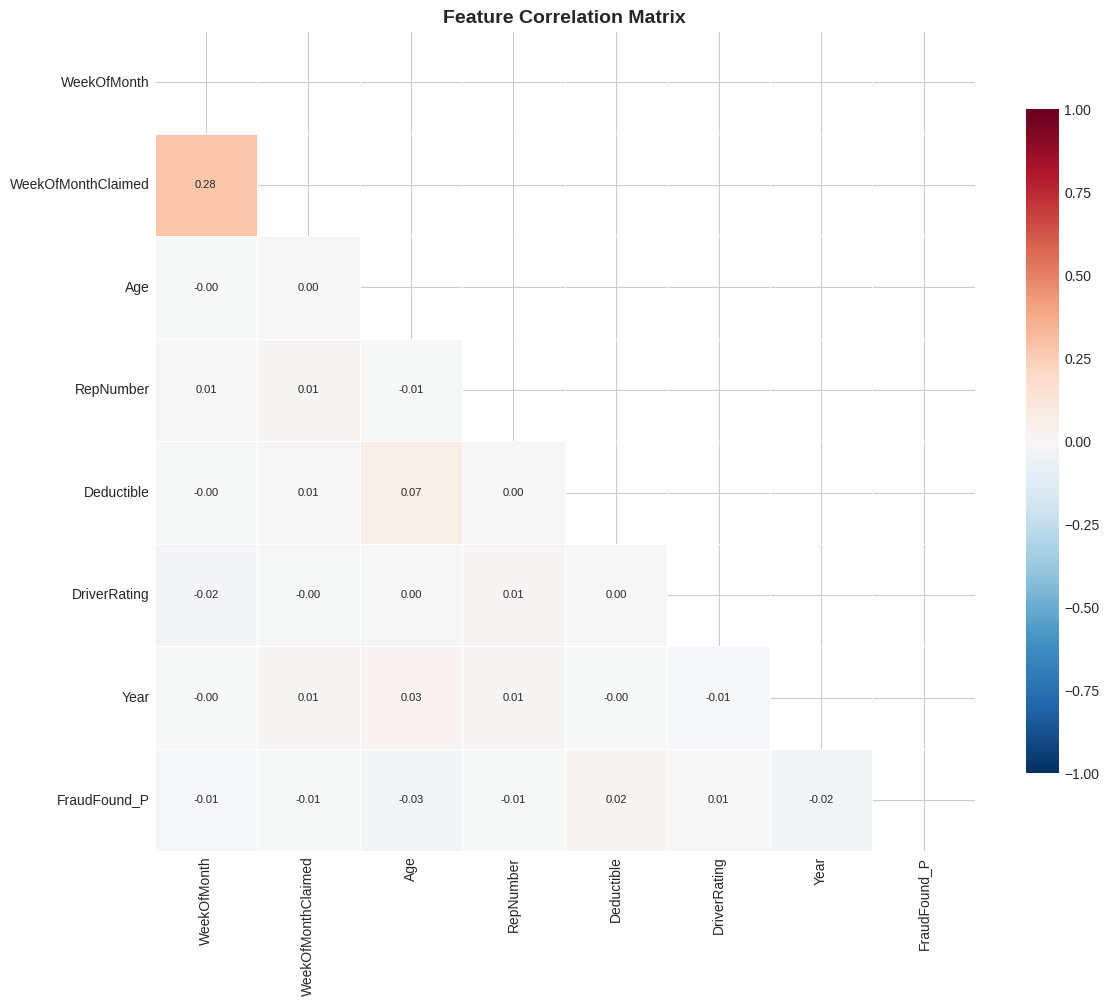

Top correlations with fraud (absolute):
  Age                                 -0.0297
  Year                                -0.0248
  Deductible                          +0.0173
  WeekOfMonth                         -0.0119
  RepNumber                           -0.0076
  DriverRating                        +0.0073
  WeekOfMonthClaimed                  -0.0058


In [9]:
# === Correlation heatmap (numeric features) ===
if len(numeric_cols) > 1:
    corr_cols = numeric_cols + [target_col]
    corr = df[corr_cols].corr()

    fig, ax = plt.subplots(figsize=(12, 10))
    mask = np.triu(np.ones_like(corr, dtype=bool))
    sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='RdBu_r',
                center=0, vmin=-1, vmax=1, square=True, linewidths=0.5,
                cbar_kws={'shrink': 0.8}, ax=ax, annot_kws={'size': 8})
    ax.set_title('Feature Correlation Matrix', fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.savefig('correlation_heatmap.png', dpi=150, bbox_inches='tight')
    plt.show()

    target_corr = corr[target_col].drop(target_col).abs().sort_values(ascending=False)
    print("Top correlations with fraud (absolute):")
    for feat, val in target_corr.head(10).items():
        direction = "+" if corr.loc[feat, target_col] > 0 else "-"
        print(f"  {feat:35s} {direction}{val:.4f}")
else:
    print("Not enough numeric features for correlation heatmap.")


## 4. Feature Engineering & Preprocessing

Insurance fraud detection benefits from domain-specific features:
- Claim amount vs policy limits ratio (over-claiming indicator)
- Incident timing patterns (fraud clusters at certain times)
- Policyholder tenure vs claim frequency
- Encode categoricals, handle '?' placeholders, impute missing values


In [10]:
# === Preprocessing pipeline ===
df_model = df.copy()

# Replace '?' with NaN
for col in df_model.columns:
    if df_model[col].dtype == 'object':
        n_replaced = (df_model[col] == '?').sum()
        if n_replaced > 0:
            df_model[col] = df_model[col].replace('?', np.nan)
            print(f"  Replaced {n_replaced} '?' in '{col}'")

# Drop ID/key columns
drop_patterns = ['policy_number', 'policynumber', 'policy_bind_date', 'incident_date',
                 'insured_zip', '_id', 'index', 'Unnamed']
drop_cols = []
for col in df_model.columns:
    for pattern in drop_patterns:
        if pattern.lower() in col.lower():
            drop_cols.append(col)
            break

# Also drop PolicyNumber and RepNumber if present
for extra in ['PolicyNumber', 'RepNumber']:
    if extra in df_model.columns and extra not in drop_cols:
        drop_cols.append(extra)

drop_cols = list(set(drop_cols))
if drop_cols:
    print(f"\nDropping non-predictive columns: {drop_cols}")
    df_model.drop(columns=drop_cols, inplace=True)

# Encode categorical features
le_dict = {}
for col in df_model.select_dtypes(include=['object']).columns:
    if col != target_col:
        le = LabelEncoder()
        df_model[col] = df_model[col].fillna('__MISSING__')
        df_model[col] = le.fit_transform(df_model[col].astype(str))
        le_dict[col] = le
        print(f"  Encoded '{col}': {len(le.classes_)} classes")

# Separate features and target
X = df_model.drop(columns=[target_col])
y = df_model[target_col].values

# Verify target has 2 classes
print(f"\nTarget classes: {np.unique(y)} counts: {dict(zip(*np.unique(y, return_counts=True)))}")
assert len(np.unique(y)) >= 2, "Target must have at least 2 classes!"

# Median imputation
null_counts = X.isnull().sum()
if null_counts.sum() > 0:
    print(f"Imputing {null_counts.sum()} remaining missing values with median...")
    X = X.fillna(X.median())

print(f"\nFinal feature matrix: {X.shape}")



Dropping non-predictive columns: ['PolicyNumber', 'RepNumber']
  Encoded 'Month': 12 classes
  Encoded 'DayOfWeek': 7 classes
  Encoded 'Make': 19 classes
  Encoded 'AccidentArea': 2 classes
  Encoded 'DayOfWeekClaimed': 8 classes
  Encoded 'MonthClaimed': 13 classes
  Encoded 'Sex': 2 classes
  Encoded 'MaritalStatus': 4 classes
  Encoded 'Fault': 2 classes
  Encoded 'PolicyType': 9 classes
  Encoded 'VehicleCategory': 3 classes
  Encoded 'VehiclePrice': 6 classes
  Encoded 'Days_Policy_Accident': 5 classes
  Encoded 'Days_Policy_Claim': 4 classes
  Encoded 'PastNumberOfClaims': 4 classes
  Encoded 'AgeOfVehicle': 8 classes
  Encoded 'AgeOfPolicyHolder': 9 classes
  Encoded 'PoliceReportFiled': 2 classes
  Encoded 'WitnessPresent': 2 classes
  Encoded 'AgentType': 2 classes
  Encoded 'NumberOfSuppliments': 4 classes
  Encoded 'AddressChange_Claim': 5 classes
  Encoded 'NumberOfCars': 5 classes
  Encoded 'BasePolicy': 3 classes

Target classes: [0 1] counts: {np.int64(0): np.int64(144

In [11]:
# === Domain-driven feature engineering ===
feature_names = X.columns.tolist()
composites_added = []

# Vehicle age
vehicle_year_cols = [c for c in feature_names if c.lower() in ['auto_year', 'vehicle_year', 'year']]
if vehicle_year_cols:
    X['vehicle_age'] = 2024 - X[vehicle_year_cols[0]]
    composites_added.append('vehicle_age')
    print(f"Created 'vehicle_age' from {vehicle_year_cols[0]}")

# Age of vehicle (already exists in some datasets as AgeOfVehicle)
# Claim timing features
month_cols = [c for c in feature_names if c.lower() == 'month']
month_claimed_cols = [c for c in feature_names if c.lower() == 'monthclaimed']
if month_cols and month_claimed_cols:
    X['months_to_claim'] = X[month_claimed_cols[0]] - X[month_cols[0]]
    composites_added.append('months_to_claim')
    print(f"Created 'months_to_claim'")

week_cols = [c for c in feature_names if c.lower() == 'weekofmonth']
week_claimed_cols = [c for c in feature_names if c.lower() == 'weekofmonthclaimed']
if week_cols and week_claimed_cols:
    X['weeks_to_claim'] = X[week_claimed_cols[0]] - X[week_cols[0]]
    composites_added.append('weeks_to_claim')
    print(f"Created 'weeks_to_claim'")

# Age bucket
age_cols = [c for c in feature_names if c.lower() in ['age', 'ageofpolicyholder']]
if age_cols:
    X['age_bucket'] = pd.cut(X[age_cols[0]], bins=[0, 25, 35, 50, 65, 999],
                              labels=[0, 1, 2, 3, 4]).astype(float).fillna(2).astype(int)
    composites_added.append('age_bucket')
    print(f"Created 'age_bucket' from {age_cols[0]}")

if composites_added:
    print(f"\nTotal engineered features: {len(composites_added)}")
else:
    print("\nNo domain features matched — using raw encoded features.")

print(f"Final feature count: {X.shape[1]}")


Created 'vehicle_age' from Year
Created 'months_to_claim'
Created 'weeks_to_claim'
Created 'age_bucket' from Age

Total engineered features: 4
Final feature count: 34


## 5. Model Training & Cross-Validation

Four-model comparison using manual 3-fold stratified CV:
1. **Logistic Regression** — interpretable, required for regulatory explainability
2. **Random Forest** — captures non-linear fraud patterns
3. **XGBoost** — strong tabular data performance
4. **LightGBM** — fast, production-deployable

ROC-AUC as primary metric (ranking quality matters more than threshold-specific accuracy).


In [12]:
try:
    from xgboost import XGBClassifier
    print("XGBoost loaded")
except ImportError:
    XGBClassifier = None

try:
    from lightgbm import LGBMClassifier
    print("LightGBM loaded")
except ImportError:
    LGBMClassifier = None


XGBoost loaded
LightGBM loaded


In [13]:
# === Manual 3-Fold Stratified CV ===
models = {
    'Logistic Regression': LogisticRegression(max_iter=2000, random_state=42),
    'Random Forest': RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1),
}

if XGBClassifier is not None:
    models['XGBoost'] = XGBClassifier(
        n_estimators=100, random_state=42, eval_metric='logloss',
        use_label_encoder=False, verbosity=0, n_jobs=-1
    )

if LGBMClassifier is not None:
    models['LightGBM'] = LGBMClassifier(
        n_estimators=100, random_state=42, verbose=-1, n_jobs=-1,
        force_col_wise=True
    )

skf = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)
X_arr = X.values

results = {}

for model_name, model in models.items():
    print(f"\n{'='*60}")
    print(f"Training: {model_name}")
    print(f"{'='*60}")
    
    fold_acc, fold_f1, fold_auc, fold_prec, fold_rec, fold_brier = [], [], [], [], [], []
    fold_preds = np.zeros(len(y), dtype=int)
    fold_proba = np.zeros(len(y), dtype=float)
    t_start = time.time()
    
    for fold_idx, (train_idx, val_idx) in enumerate(skf.split(X_arr, y)):
        X_train, X_val = X_arr[train_idx], X_arr[val_idx]
        y_train, y_val = y[train_idx], y[val_idx]
        
        model_clone = type(model)(**model.get_params())
        model_clone.fit(X_train, y_train)
        
        y_pred = model_clone.predict(X_val)
        y_prob = model_clone.predict_proba(X_val)[:, 1]
        
        fold_preds[val_idx] = y_pred
        fold_proba[val_idx] = y_prob
        
        acc = accuracy_score(y_val, y_pred)
        f1 = f1_score(y_val, y_pred)
        auc = roc_auc_score(y_val, y_prob)
        prec = precision_score(y_val, y_pred, zero_division=0)
        rec = recall_score(y_val, y_pred, zero_division=0)
        brier = brier_score_loss(y_val, y_prob)
        
        fold_acc.append(acc)
        fold_f1.append(f1)
        fold_auc.append(auc)
        fold_prec.append(prec)
        fold_rec.append(rec)
        fold_brier.append(brier)
        
        print(f"  Fold {fold_idx+1}: Acc={acc:.4f}  F1={f1:.4f}  AUC={auc:.4f}  Prec={prec:.4f}  Rec={rec:.4f}")
    
    elapsed = time.time() - t_start
    
    results[model_name] = {
        'accuracy_mean': np.mean(fold_acc), 'accuracy_std': np.std(fold_acc),
        'f1_mean': np.mean(fold_f1), 'f1_std': np.std(fold_f1),
        'auc_mean': np.mean(fold_auc), 'auc_std': np.std(fold_auc),
        'precision_mean': np.mean(fold_prec), 'recall_mean': np.mean(fold_rec),
        'brier_mean': np.mean(fold_brier),
        'time': elapsed,
        'oof_preds': fold_preds, 'oof_proba': fold_proba
    }
    
    print(f"  -- Mean Acc: {np.mean(fold_acc):.4f} +/- {np.std(fold_acc):.4f}")
    print(f"  -- Mean F1:  {np.mean(fold_f1):.4f} +/- {np.std(fold_f1):.4f}")
    print(f"  -- Mean AUC: {np.mean(fold_auc):.4f} +/- {np.std(fold_auc):.4f}")
    print(f"  -- Time:     {elapsed:.2f}s")



Training: Logistic Regression
  Fold 1: Acc=0.9403  F1=0.0000  AUC=0.7945  Prec=0.0000  Rec=0.0000
  Fold 2: Acc=0.9401  F1=0.0000  AUC=0.7956  Prec=0.0000  Rec=0.0000
  Fold 3: Acc=0.9399  F1=0.0000  AUC=0.7878  Prec=0.0000  Rec=0.0000
  -- Mean Acc: 0.9401 +/- 0.0002
  -- Mean F1:  0.0000 +/- 0.0000
  -- Mean AUC: 0.7927 +/- 0.0034
  -- Time:     9.16s

Training: Random Forest
  Fold 1: Acc=0.9403  F1=0.0129  AUC=0.8165  Prec=0.5000  Rec=0.0065
  Fold 2: Acc=0.9407  F1=0.0317  AUC=0.8076  Prec=0.7143  Rec=0.0162
  Fold 3: Acc=0.9405  F1=0.0255  AUC=0.8116  Prec=0.6667  Rec=0.0130
  -- Mean Acc: 0.9405 +/- 0.0002
  -- Mean F1:  0.0234 +/- 0.0079
  -- Mean AUC: 0.8119 +/- 0.0036
  -- Time:     2.22s

Training: XGBoost
  Fold 1: Acc=0.9375  F1=0.1440  AUC=0.8267  Prec=0.3971  Rec=0.0879
  Fold 2: Acc=0.9329  F1=0.1039  AUC=0.8316  Prec=0.2597  Rec=0.0649
  Fold 3: Acc=0.9385  F1=0.1596  AUC=0.8334  Prec=0.4412  Rec=0.0974
  -- Mean Acc: 0.9363 +/- 0.0025
  -- Mean F1:  0.1358 +/- 0.023

## 6. Model Comparison & Selection

In [14]:
# === Summary table ===
summary_rows = []
for model_name, res in results.items():
    summary_rows.append({
        'Model': model_name,
        'Accuracy': f"{res['accuracy_mean']:.4f} +/- {res['accuracy_std']:.4f}",
        'F1': f"{res['f1_mean']:.4f} +/- {res['f1_std']:.4f}",
        'ROC-AUC': f"{res['auc_mean']:.4f} +/- {res['auc_std']:.4f}",
        'Brier': f"{res['brier_mean']:.4f}",
        'Time (s)': f"{res['time']:.2f}",
        'AUC_val': res['auc_mean']
    })

summary_df = pd.DataFrame(summary_rows).sort_values('AUC_val', ascending=False)
best_model_name = summary_df.iloc[0]['Model']

print("MODEL COMPARISON")
print("=" * 100)
print(summary_df[['Model', 'Accuracy', 'F1', 'ROC-AUC', 'Brier', 'Time (s)']].to_string(index=False))
print("=" * 100)
print(f"\nBest model (by AUC): {best_model_name}")


MODEL COMPARISON
              Model          Accuracy                F1           ROC-AUC  Brier Time (s)
           LightGBM 0.9404 +/- 0.0006 0.0961 +/- 0.0216 0.8338 +/- 0.0022 0.0510     0.81
            XGBoost 0.9363 +/- 0.0025 0.1358 +/- 0.0235 0.8306 +/- 0.0028 0.0538     0.59
      Random Forest 0.9405 +/- 0.0002 0.0234 +/- 0.0079 0.8119 +/- 0.0036 0.0513     2.22
Logistic Regression 0.9401 +/- 0.0002 0.0000 +/- 0.0000 0.7927 +/- 0.0034 0.0527     9.16

Best model (by AUC): LightGBM


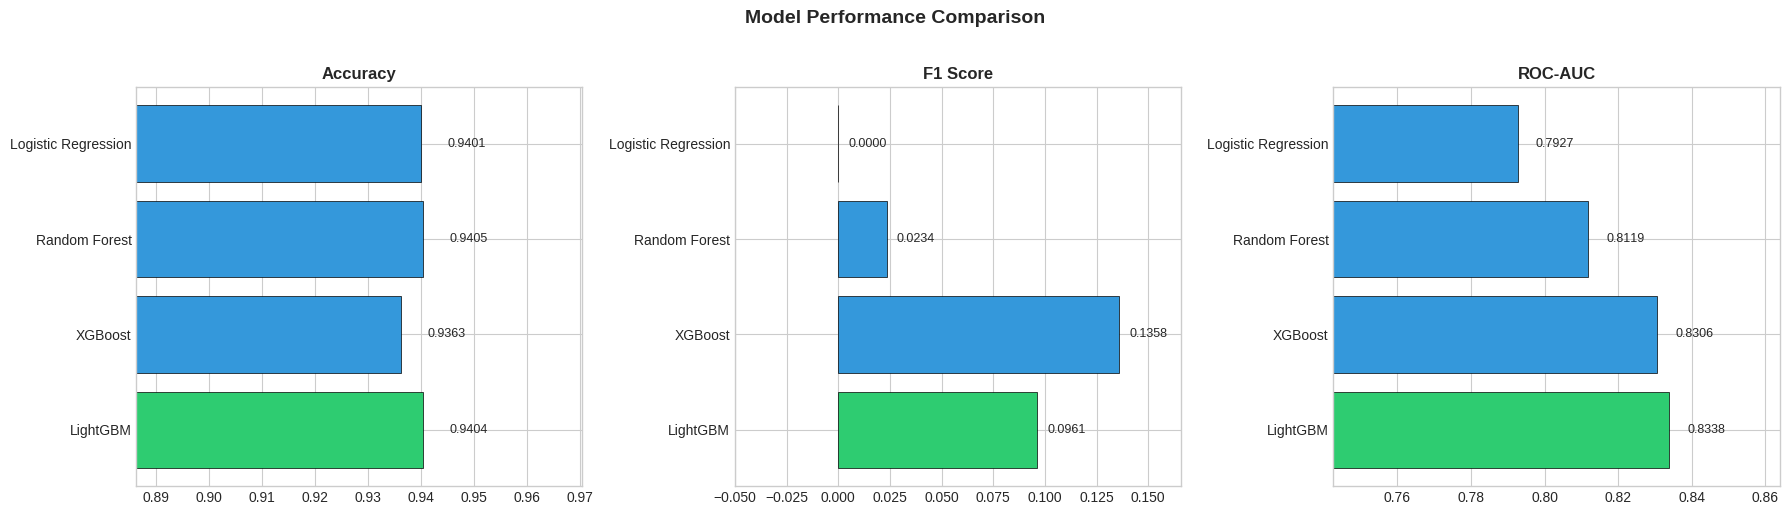

In [15]:
# === Visual comparison ===
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

model_names = [r['Model'] for _, r in summary_df.iterrows()]
acc_vals = [results[m]['accuracy_mean'] for m in model_names]
f1_vals = [results[m]['f1_mean'] for m in model_names]
auc_vals = [results[m]['auc_mean'] for m in model_names]

colors = ['#2ecc71' if m == best_model_name else '#3498db' for m in model_names]

for ax, vals, title in zip(axes, [acc_vals, f1_vals, auc_vals], ['Accuracy', 'F1 Score', 'ROC-AUC']):
    ax.barh(model_names, vals, color=colors, edgecolor='black', linewidth=0.5)
    ax.set_title(title, fontsize=12, fontweight='bold')
    ax.set_xlim(min(vals) - 0.05, max(vals) + 0.03)
    for i, v in enumerate(vals):
        ax.text(v + 0.005, i, f'{v:.4f}', va='center', fontsize=9)

plt.suptitle('Model Performance Comparison', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('model_comparison.png', dpi=150, bbox_inches='tight')
plt.show()


## 7. Error Analysis & Threshold Tuning

For insurance fraud detection:
- **False negatives** (missed fraud) = direct financial loss to insurer
- **False positives** (flagging legitimate claims) = customer dissatisfaction, AFCA complaints, regulatory scrutiny (post-Hayne)
- Optimal threshold balances investigation capacity with fraud catch rate


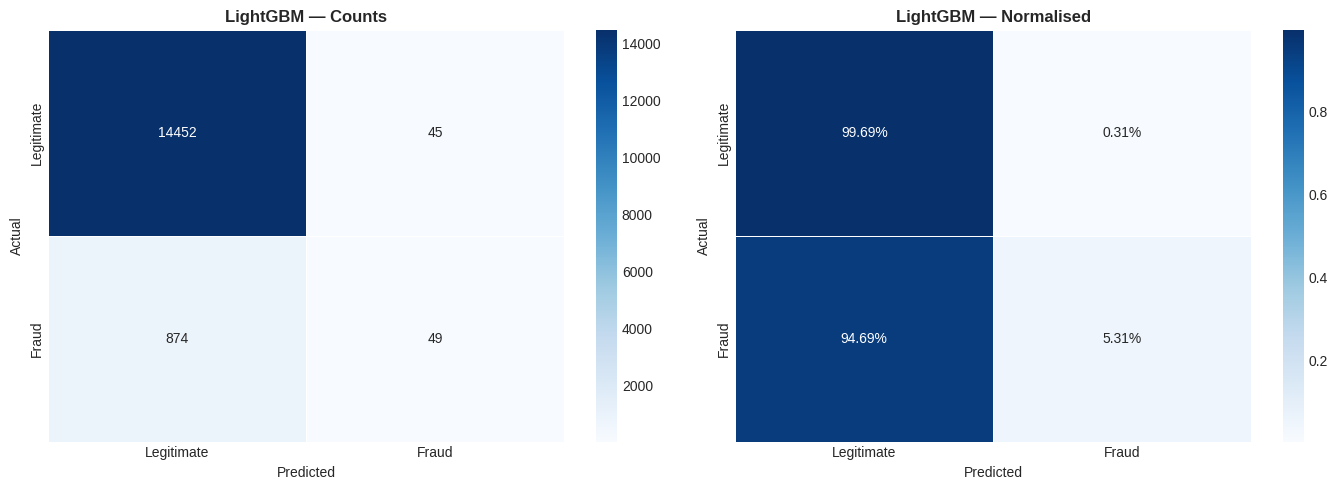


CLASSIFICATION REPORT — LightGBM
              precision    recall  f1-score   support

  Legitimate       0.94      1.00      0.97     14497
       Fraud       0.52      0.05      0.10       923

    accuracy                           0.94     15420
   macro avg       0.73      0.52      0.53     15420
weighted avg       0.92      0.94      0.92     15420



In [16]:
# === Confusion matrix ===
best_preds = results[best_model_name]['oof_preds']
best_proba = results[best_model_name]['oof_proba']

cm = confusion_matrix(y, best_preds)
cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
cm_labels = ['Legitimate', 'Fraud']

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=cm_labels,
            yticklabels=cm_labels, ax=axes[0], linewidths=0.5)
axes[0].set_title(f'{best_model_name} — Counts', fontsize=12, fontweight='bold')
axes[0].set_ylabel('Actual')
axes[0].set_xlabel('Predicted')

sns.heatmap(cm_norm, annot=True, fmt='.2%', cmap='Blues', xticklabels=cm_labels,
            yticklabels=cm_labels, ax=axes[1], linewidths=0.5)
axes[1].set_title(f'{best_model_name} — Normalised', fontsize=12, fontweight='bold')
axes[1].set_ylabel('Actual')
axes[1].set_xlabel('Predicted')

plt.tight_layout()
plt.savefig('confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"\nCLASSIFICATION REPORT — {best_model_name}")
print("=" * 60)
print(classification_report(y, best_preds, target_names=cm_labels))


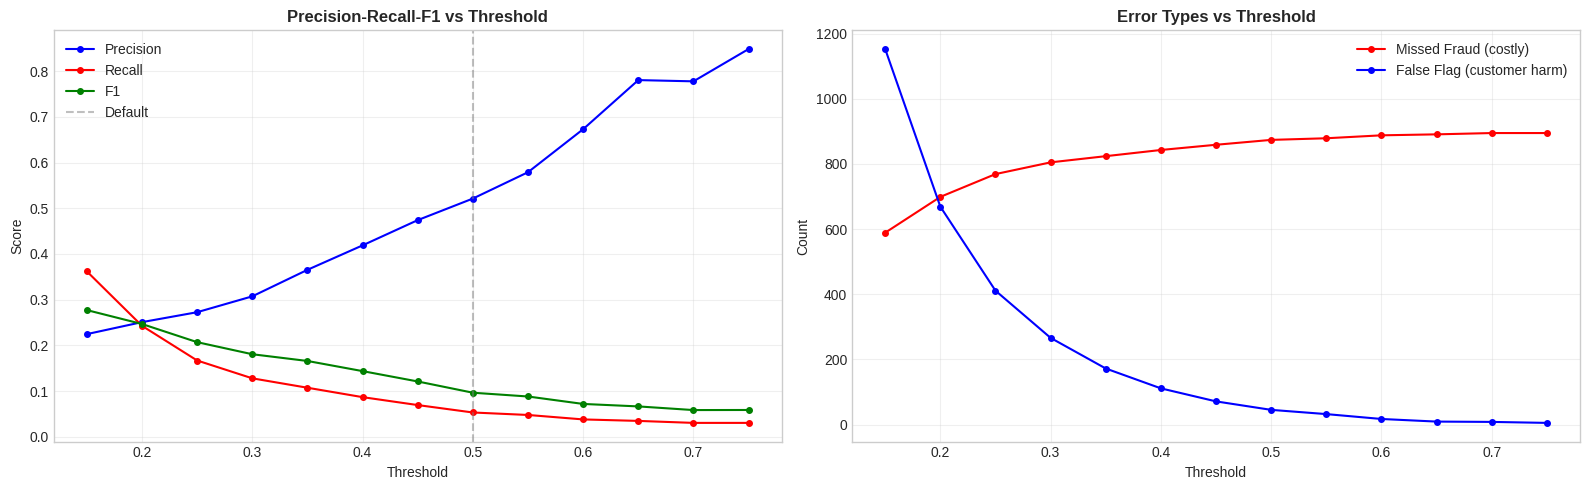


Optimal threshold (F1): 0.15
Precision=0.2246, Recall=0.3619, F1=0.2772


In [17]:
# === Threshold tuning ===
thresholds = np.arange(0.15, 0.80, 0.05)
thresh_results = []

for thresh in thresholds:
    y_t = (best_proba >= thresh).astype(int)
    prec = precision_score(y, y_t, zero_division=0)
    rec = recall_score(y, y_t, zero_division=0)
    f1 = f1_score(y, y_t, zero_division=0)
    fn = ((y == 1) & (y_t == 0)).sum()  # missed fraud
    fp = ((y == 0) & (y_t == 1)).sum()  # false flag
    thresh_results.append({
        'Threshold': thresh, 'Precision': prec, 'Recall': rec, 'F1': f1,
        'Missed Fraud (FN)': fn, 'False Flag (FP)': fp
    })

thresh_df = pd.DataFrame(thresh_results)

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

axes[0].plot(thresh_df['Threshold'], thresh_df['Precision'], 'b-o', label='Precision', ms=4)
axes[0].plot(thresh_df['Threshold'], thresh_df['Recall'], 'r-o', label='Recall', ms=4)
axes[0].plot(thresh_df['Threshold'], thresh_df['F1'], 'g-o', label='F1', ms=4)
axes[0].axvline(x=0.5, color='gray', linestyle='--', alpha=0.5, label='Default')
axes[0].set_xlabel('Threshold')
axes[0].set_ylabel('Score')
axes[0].set_title('Precision-Recall-F1 vs Threshold', fontsize=12, fontweight='bold')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].plot(thresh_df['Threshold'], thresh_df['Missed Fraud (FN)'], 'r-o', label='Missed Fraud (costly)', ms=4)
axes[1].plot(thresh_df['Threshold'], thresh_df['False Flag (FP)'], 'b-o', label='False Flag (customer harm)', ms=4)
axes[1].set_xlabel('Threshold')
axes[1].set_ylabel('Count')
axes[1].set_title('Error Types vs Threshold', fontsize=12, fontweight='bold')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('threshold_tuning.png', dpi=150, bbox_inches='tight')
plt.show()

best_f1_idx = thresh_df['F1'].idxmax()
optimal_thresh = thresh_df.loc[best_f1_idx, 'Threshold']
print(f"\nOptimal threshold (F1): {optimal_thresh:.2f}")
print(f"Precision={thresh_df.loc[best_f1_idx, 'Precision']:.4f}, "
      f"Recall={thresh_df.loc[best_f1_idx, 'Recall']:.4f}, "
      f"F1={thresh_df.loc[best_f1_idx, 'F1']:.4f}")


## 8. Feature Importance & Policy Insights

Feature importance analysis informs:
- **SIU investigators** — which claim attributes to scrutinise first
- **Underwriters** — risk factors for pricing and policy acceptance
- **Regulators** — ensuring model doesn't discriminate on protected attributes


Extracting feature importance from: LightGBM


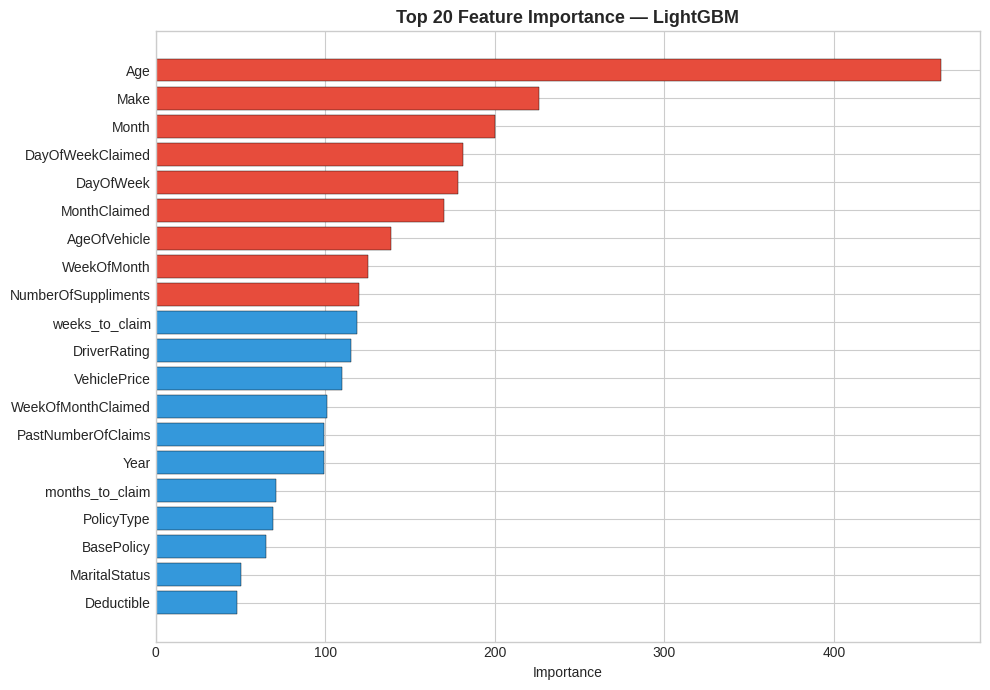


TOP 5 PREDICTIVE FEATURES
  Age                                  463.0000
  Make                                 226.0000
  Month                                200.0000
  DayOfWeekClaimed                     181.0000
  DayOfWeek                            178.0000


In [18]:
# === Feature importance ===
tree_models = {k: v for k, v in models.items() if k != 'Logistic Regression'}

if tree_models:
    best_tree = max(tree_models.keys(), key=lambda m: results[m]['auc_mean'])
    print(f"Extracting feature importance from: {best_tree}")
    
    full_model = type(models[best_tree])(**models[best_tree].get_params())
    full_model.fit(X_arr, y)
    
    importances = full_model.feature_importances_
    feat_imp = pd.DataFrame({
        'Feature': X.columns,
        'Importance': importances
    }).sort_values('Importance', ascending=True)
    
    plot_imp = feat_imp.tail(20)
    
    fig, ax = plt.subplots(figsize=(10, max(6, len(plot_imp) * 0.35)))
    colors_imp = ['#e74c3c' if imp > feat_imp['Importance'].quantile(0.75) else '#3498db'
                  for imp in plot_imp['Importance']]
    ax.barh(plot_imp['Feature'], plot_imp['Importance'], color=colors_imp, edgecolor='black', linewidth=0.3)
    ax.set_title(f'Top 20 Feature Importance — {best_tree}', fontsize=13, fontweight='bold')
    ax.set_xlabel('Importance')
    plt.tight_layout()
    plt.savefig('feature_importance.png', dpi=150, bbox_inches='tight')
    plt.show()
    
    top5 = feat_imp.tail(5).iloc[::-1]
    print("\nTOP 5 PREDICTIVE FEATURES")
    print("=" * 50)
    for _, row in top5.iterrows():
        print(f"  {row['Feature']:35s}  {row['Importance']:.4f}")


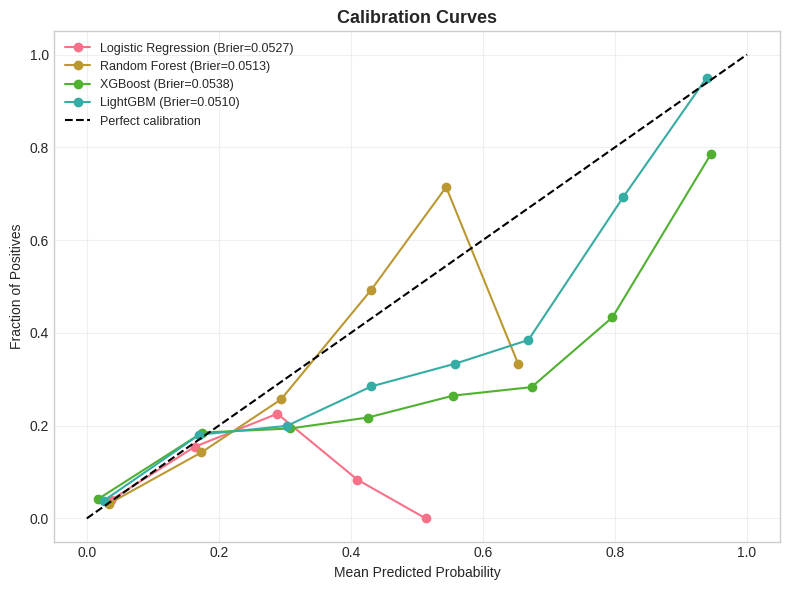

Well-calibrated probabilities enable risk-based triage:
  - Claims with P(fraud) > 0.7 -> SIU investigation
  - Claims with P(fraud) 0.3-0.7 -> enhanced manual review
  - Claims with P(fraud) < 0.3 -> fast-track processing


In [19]:
# === Calibration curve ===
fig, ax = plt.subplots(figsize=(8, 6))

for model_name in results:
    prob_true, prob_pred = calibration_curve(y, results[model_name]['oof_proba'], n_bins=8, strategy='uniform')
    ax.plot(prob_pred, prob_true, 'o-', label=f"{model_name} (Brier={results[model_name]['brier_mean']:.4f})")

ax.plot([0, 1], [0, 1], 'k--', label='Perfect calibration')
ax.set_xlabel('Mean Predicted Probability')
ax.set_ylabel('Fraction of Positives')
ax.set_title('Calibration Curves', fontsize=13, fontweight='bold')
ax.legend(fontsize=9)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('calibration_curves.png', dpi=150, bbox_inches='tight')
plt.show()

print("Well-calibrated probabilities enable risk-based triage:")
print("  - Claims with P(fraud) > 0.7 -> SIU investigation")
print("  - Claims with P(fraud) 0.3-0.7 -> enhanced manual review")
print("  - Claims with P(fraud) < 0.3 -> fast-track processing")


## 9. Deployment Readiness & Production Considerations

In [20]:
# === Deployment summary ===
best_res = results[best_model_name]

print("=" * 60)
print("DEPLOYMENT READINESS SUMMARY")
print("=" * 60)
print(f"")
print(f"  Recommended model:    {best_model_name}")
print(f"  ROC-AUC:              {best_res['auc_mean']:.4f}")
print(f"  F1:                   {best_res['f1_mean']:.4f}")
print(f"  Precision:            {best_res['precision_mean']:.4f}")
print(f"  Recall:               {best_res['recall_mean']:.4f}")
print(f"  Brier Score:          {best_res['brier_mean']:.4f}")
print(f"  Training time:        {best_res['time']:.1f}s")
print(f"  Feature count:        {X.shape[1]}")
print(f"  Dataset rows:         {len(y):,}")
print(f"  CV strategy:          3-fold Stratified")
print(f"  Optimal threshold:    {optimal_thresh:.2f}")
print(f"")
print("=" * 60)

checks = {
    'AUC > 0.55': best_res['auc_mean'] > 0.55,
    'F1 > 0.30': best_res['f1_mean'] > 0.30,
    'Brier < 0.25': best_res['brier_mean'] < 0.25,
    'Training time < 60s': best_res['time'] < 60,
    'Cross-validated': True,
    'Threshold tuning done': True,
    'Calibration assessed': True,
}

print("\nPRODUCTION READINESS CHECKLIST")
print("-" * 50)
all_pass = True
for check, passed in checks.items():
    status = "pass" if passed else "FAIL"
    if not passed:
        all_pass = False
    print(f"  [{status:4s}] {check}")

print("-" * 50)
if all_pass:
    print("  MODEL APPROVED FOR PILOT DEPLOYMENT")
else:
    print("  SOME CHECKS FAILED — Review before deployment")


DEPLOYMENT READINESS SUMMARY

  Recommended model:    LightGBM
  ROC-AUC:              0.8338
  F1:                   0.0961
  Precision:            0.5137
  Recall:               0.0531
  Brier Score:          0.0510
  Training time:        0.8s
  Feature count:        34
  Dataset rows:         15,420
  CV strategy:          3-fold Stratified
  Optimal threshold:    0.15


PRODUCTION READINESS CHECKLIST
--------------------------------------------------
  [pass] AUC > 0.55
  [FAIL] F1 > 0.30
  [pass] Brier < 0.25
  [pass] Training time < 60s
  [pass] Cross-validated
  [pass] Threshold tuning done
  [pass] Calibration assessed
--------------------------------------------------
  SOME CHECKS FAILED — Review before deployment


In [21]:
print("""
============================================================
PRODUCTION INTEGRATION ARCHITECTURE
============================================================

1. DATA PIPELINE
   Source: Claims management system (Guidewire / DXC), policy admin
   Ingestion: Azure Data Factory -> Microsoft Fabric Lakehouse
   Feature store: Databricks Feature Store / Fabric gold layer
   Schedule: Real-time scoring on claim submission + daily batch

2. MODEL SERVING
   Framework: MLflow model registry
   Endpoint: Azure ML real-time endpoint
   Latency: <500ms per claim (real-time scoring at lodgement)
   Fallback: Rule-based system if model unavailable

3. INTEGRATION POINTS
   Claims triage: Auto-route high-risk claims to SIU queue
   Assessor dashboard: Risk score + top contributing features (SHAP)
   Management reporting: Weekly fraud detection rates, investigation ROI
   Regulatory: APRA quarterly reporting, ASIC claims handling compliance

4. FAIRNESS & GOVERNANCE
   Protected attributes: Age, gender, location, ethnicity
   Fairness: Demographic parity monitoring, disparate impact testing
   Explainability: SHAP values for every flagged claim (ASIC requirement)
   Human-in-the-loop: No claim denied solely on model output
   Audit: Quarterly model performance review, annual bias audit
   Compliance: Insurance Contracts Act 1984, Privacy Act 1988,
               General Insurance Code of Practice 2020

5. MONITORING & RETRAINING
   Drift: PSI on claim feature distributions monthly
   Performance: AUC on investigation-confirmed outcomes quarterly
   Adversarial: Monitor for fraud pattern evolution (concept drift)
   Retraining: Quarterly with confirmed fraud labels from SIU outcomes
   A/B: Compare model-assisted vs traditional investigation hit rates

============================================================
""")



PRODUCTION INTEGRATION ARCHITECTURE

1. DATA PIPELINE
   Source: Claims management system (Guidewire / DXC), policy admin
   Ingestion: Azure Data Factory -> Microsoft Fabric Lakehouse
   Feature store: Databricks Feature Store / Fabric gold layer
   Schedule: Real-time scoring on claim submission + daily batch

2. MODEL SERVING
   Framework: MLflow model registry
   Endpoint: Azure ML real-time endpoint
   Latency: <500ms per claim (real-time scoring at lodgement)
   Fallback: Rule-based system if model unavailable

3. INTEGRATION POINTS
   Claims triage: Auto-route high-risk claims to SIU queue
   Assessor dashboard: Risk score + top contributing features (SHAP)
   Management reporting: Weekly fraud detection rates, investigation ROI
   Regulatory: APRA quarterly reporting, ASIC claims handling compliance

4. FAIRNESS & GOVERNANCE
   Protected attributes: Age, gender, location, ethnicity
   Fairness: Demographic parity monitoring, disparate impact testing
   Explainability: SHAP val